In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [13]:
df = pd.read_excel('BaseUnificadaEstaciones.xlsx', parse_dates=['FECHA'], date_format='mixed')

In [14]:
df.shape

(822363, 6)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822363 entries, 0 to 822362
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   FECHA     822363 non-null  datetime64[ns]
 1   ESTACION  822363 non-null  object        
 2   LINEA     822363 non-null  object        
 3   DESDE     822363 non-null  object        
 4   HORA      822363 non-null  int64         
 5   CANTIDAD  822363 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 37.6+ MB


In [16]:
df.isnull().sum()

FECHA       0
ESTACION    0
LINEA       0
DESDE       0
HORA        0
CANTIDAD    0
dtype: int64

No hay valores nulos registrados.

In [17]:
df.describe(include='all')

,FECHA,ESTACION,LINEA,DESDE,HORA,CANTIDAD
count,822363,822363,822363,822363,822363.000000,822363.000000
unique,NaN,89,6,86,NaN,NaN
top,NaN,Carlos Pellegrini,D,18:15:00,NaN,NaN
freq,NaN,16571,191819,13458,NaN,NaN
mean,2020-07-03 10:34:49.993834240,NaN,NaN,NaN,13.368358,31.994799
min,2020-01-03 00:00:00,NaN,NaN,NaN,0.000000,1.000000
25%,2020-04-21 00:00:00,NaN,NaN,NaN,9.000000,5.000000
50%,2020-07-05 00:00:00,NaN,NaN,NaN,13.000000,12.000000
75%,2020-09-18 00:00:00,NaN,NaN,NaN,17.000000,29.000000
max,2020-12-11 00:00:00,NaN,NaN,NaN,23.000000,3827.000000


In [18]:
df.head()

,FECHA,ESTACION,LINEA,DESDE,HORA,CANTIDAD
0,2020-01-03,Acoyte,A,07:45:00,7,20
1,2020-01-03,Acoyte,A,08:00:00,8,16
2,2020-01-03,Acoyte,A,08:15:00,8,22
3,2020-01-03,Acoyte,A,08:30:00,8,27
4,2020-01-03,Acoyte,A,08:45:00,8,37


In [19]:
df['FECHA'] = pd.to_datetime(df['FECHA'], format='mixed')
df['FECHA'].max() - df['FECHA'].min()

Timedelta('343 days 00:00:00')

El dataFrame abarca 343 días del año 2020.

In [20]:
df['HORA'].value_counts()

HORA
18    53617
14    53452
17    53408
13    53388
15    53232
16    53093
12    53069
8     52887
19    52872
11    52847
10    52525
9     52352
20    51089
7     45979
6     43104
21    25054
5     11257
22     6405
23     2713
4         7
3         4
1         3
2         3
0         3
Name: count, dtype: int64

La cantidad de registros entre las 00 y las 4 son muy pequeños en comparación con las demas horas.

In [21]:
df['HORA'].value_counts().describe()

count       24.000000
mean     34265.125000
std      23769.605148
min          3.000000
25%       5482.000000
50%      51720.500000
75%      53075.000000
max      53617.000000
Name: count, dtype: float64

Hay registros para las 24 horas del día.
La media de registros es de 34k.
La mediana de registros es de 51k.

In [22]:
df['LINEA'].value_counts().describe()

count         6.000000
mean     137060.500000
std       37319.076734
min       81852.000000
25%      119212.500000
50%      140443.500000
75%      151863.000000
max      191819.000000
Name: count, dtype: float64

Hay registros para 6 líneas de subte.
La media de registros es de 137k.
La mediana de registros es de 140k.

In [23]:
df['LINEA'].value_counts()

LINEA
D    191819
B    152458
A    150078
E    130809
H    115347
C     81852
Name: count, dtype: int64

In [24]:
df['LINEA'].value_counts(normalize=True)

LINEA
D    0.233253
B    0.185390
A    0.182496
E    0.159065
H    0.140263
C    0.099533
Name: proportion, dtype: float64

La cantidad de registros de la línea C está muy por debajo del resto de las líneas.

In [25]:
df['CANTIDAD'].describe()

count    822363.000000
mean         31.994799
std          76.414429
min           1.000000
25%           5.000000
50%          12.000000
75%          29.000000
max        3827.000000
Name: CANTIDAD, dtype: float64

La media de pasajeros por hora es de 31.
La mediana de pasajeros por hora es de 12.
La desviación standar es de 76.
La gran diferencia entre la media y la mediana, junto con el dato de la desviación estándar, nos indica que hay valores muy dispersos.

In [26]:
df['LINEA'].value_counts(normalize=True)

LINEA
D    0.233253
B    0.185390
A    0.182496
E    0.159065
H    0.140263
C    0.099533
Name: proportion, dtype: float64

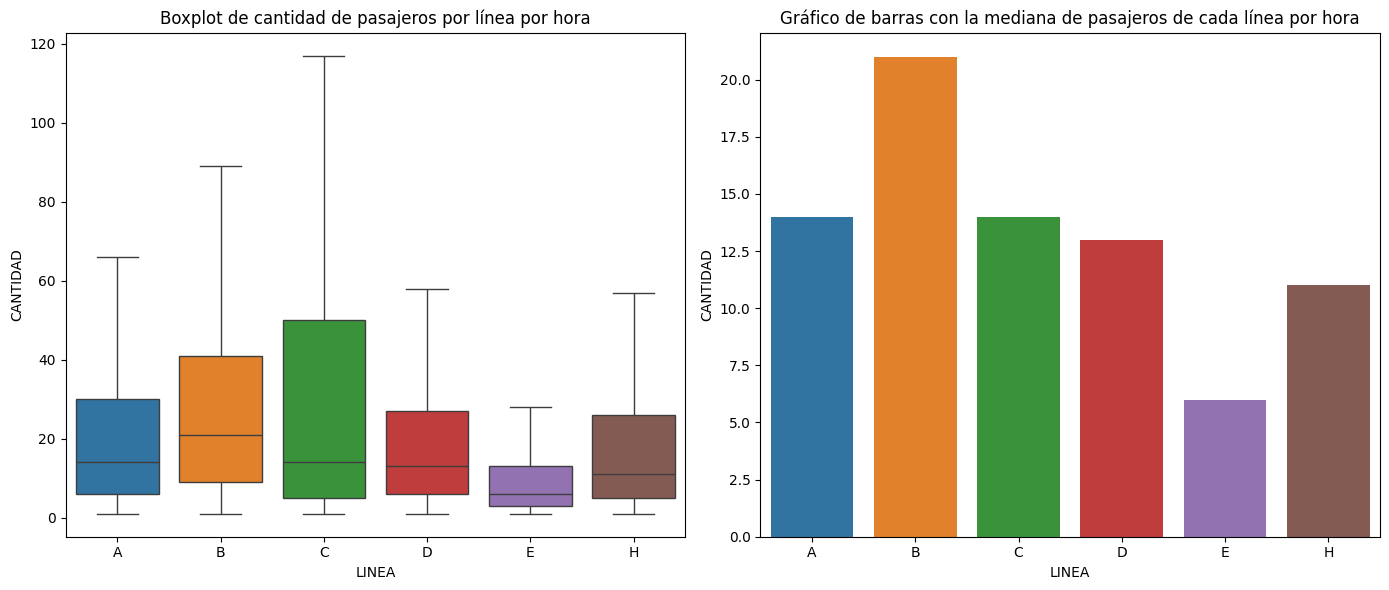

In [27]:
fig, axs = plt.subplots(1,2, figsize=(14,6))

sns.boxplot(x='LINEA', y='CANTIDAD', data=df, showfliers=False, ax=axs[0], hue='LINEA', legend=False)
axs[0].set_title('Boxplot de cantidad de pasajeros por línea por hora')

sns.barplot(x='LINEA', y='CANTIDAD', data=df, estimator=np.median, ax=axs[1], hue='LINEA', legend=False, errorbar=('ci', False))
axs[1].set_title('Gráfico de barras con la mediana de pasajeros de cada línea por hora')

plt.tight_layout()
plt.show()

La línea con la mediana más alta respecto a cantidad de pasajeros por hora es la B.
Por otro lado, vemos que la línea C tiene una distribución más amplia de pasajeros.

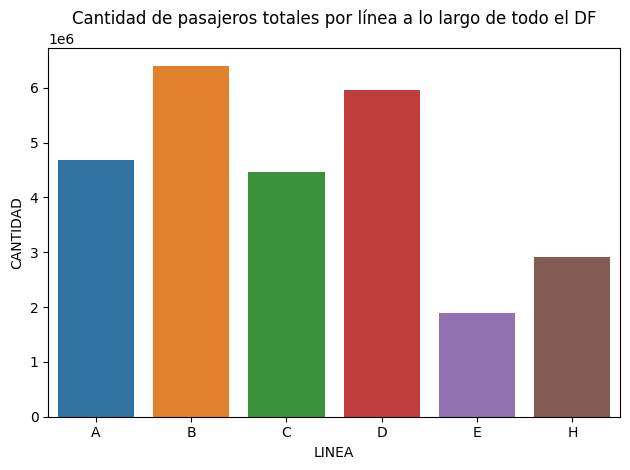

In [28]:
sns.barplot(x='LINEA', y='CANTIDAD', data=df, estimator=np.sum, hue='LINEA', legend=False, errorbar=('ci', False))
plt.title('Cantidad de pasajeros totales por línea a lo largo de todo el DF')
plt.tight_layout()
plt.show()

La línea con mayor cantidad de pasajeros a lo largo de todo el DF es la línea B con un poco más de 6 millones.

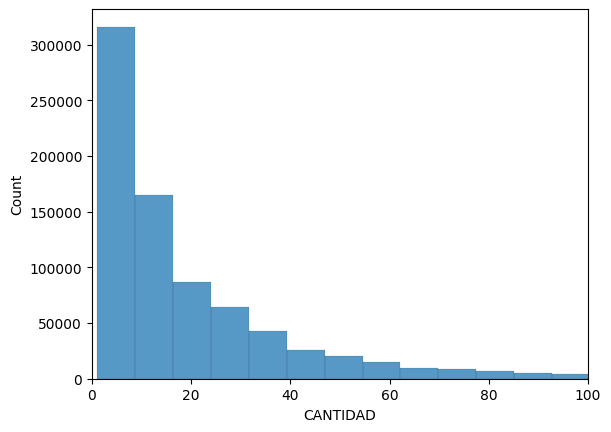

In [29]:
sns.histplot(df['CANTIDAD'], bins=500)
plt.xlim(0,100)
plt.show()

In [30]:
linea_a = df[df['LINEA']=='A']['CANTIDAD'].sum()
linea_b = df[df['LINEA']=='B']['CANTIDAD'].sum()
linea_c = df[df['LINEA']=='C']['CANTIDAD'].sum()
linea_d = df[df['LINEA']=='D']['CANTIDAD'].sum()
linea_e = df[df['LINEA']=='E']['CANTIDAD'].sum()
linea_h = df[df['LINEA']=='H']['CANTIDAD'].sum()

cantidades = {
    'A':linea_a,
    'B':linea_b,
    'C':linea_c,
    'D':linea_d,
    'E':linea_e,
    'H':linea_h
}

lineas = []
lista_cant = []

for key, value in cantidades.items():
    print(key, cantidades[key])

A 4678590
B 6405418
C 4467032
D 5956657
E 1887039
H 2916603


Verificamos las cantidades exáctas.

Las líneas B, D y A son las que más pasajeros transportan. Sin embargo, es importante notar que la línea C contiene casi la mitad de registros que el resto de las líneas.

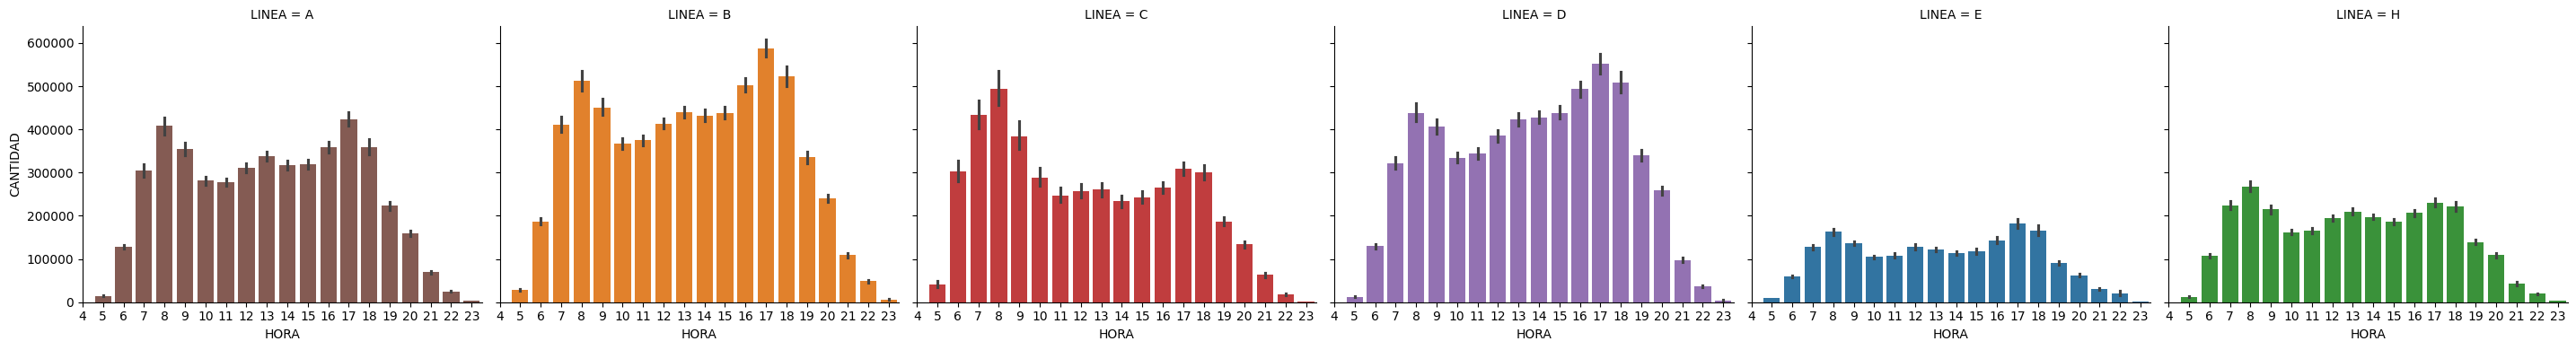

In [31]:
sns.catplot(x="HORA", y="CANTIDAD", col="LINEA", hue="LINEA", legend=False, data=df, height=4, aspect=1.2, kind='bar', estimator='sum')
plt.xticks(range(4, 24))
plt.xlim(4)
plt.show()

In [32]:
filt = df['LINEA']=='C'
linea_c = df.loc[filt]

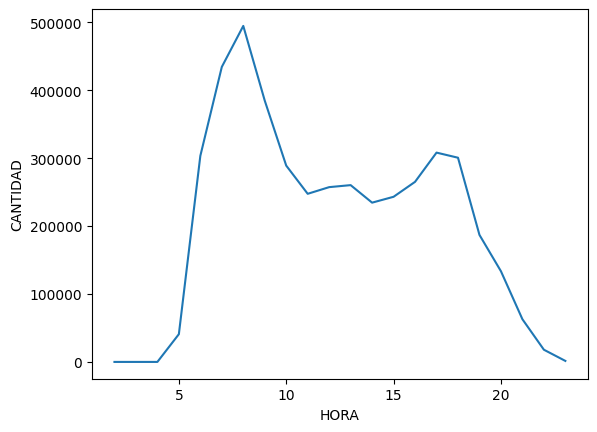

In [33]:
c_horas = linea_c.groupby('HORA', as_index=False)['CANTIDAD'].sum()

sns.lineplot(x='HORA', y='CANTIDAD', data=c_horas)
plt.show()

Si aplicamos un suavizado (estimator='mean), vemos que la línea C es la que mayor volúmen de pasajeros tiene por hora. Sin embargo, en el total de pasajeros está ubicada en el 3er lugar.
Probablemente esto se debe a que tenemos casi la mitad de registros que el resto de las líneas.

In [34]:
lineas = df.groupby('LINEA')

In [35]:
linea_a = lineas.get_group('A')
horas_a = linea_a.groupby('HORA')
cantidad_pax_a = horas_a['CANTIDAD'].sum()

In [36]:
linea_b = lineas.get_group('B')
horas_b = linea_b.groupby('HORA')
cantidad_pax_b = horas_b['CANTIDAD'].sum()

In [37]:
linea_c = lineas.get_group('C')
horas_c = linea_c.groupby('HORA')
cantidad_pax_c = horas_c['CANTIDAD'].sum()

In [38]:
linea_d = lineas.get_group('D')
horas_d = linea_d.groupby('HORA')
cantidad_pax_d = horas_d['CANTIDAD'].sum()

In [39]:
linea_e = lineas.get_group('E')
horas_e = linea_e.groupby('HORA')
cantidad_pax_e = horas_e['CANTIDAD'].sum()

In [40]:
linea_h = lineas.get_group('H')
horas_h = linea_h.groupby('HORA')
cantidad_pax_h = horas_h['CANTIDAD'].sum()

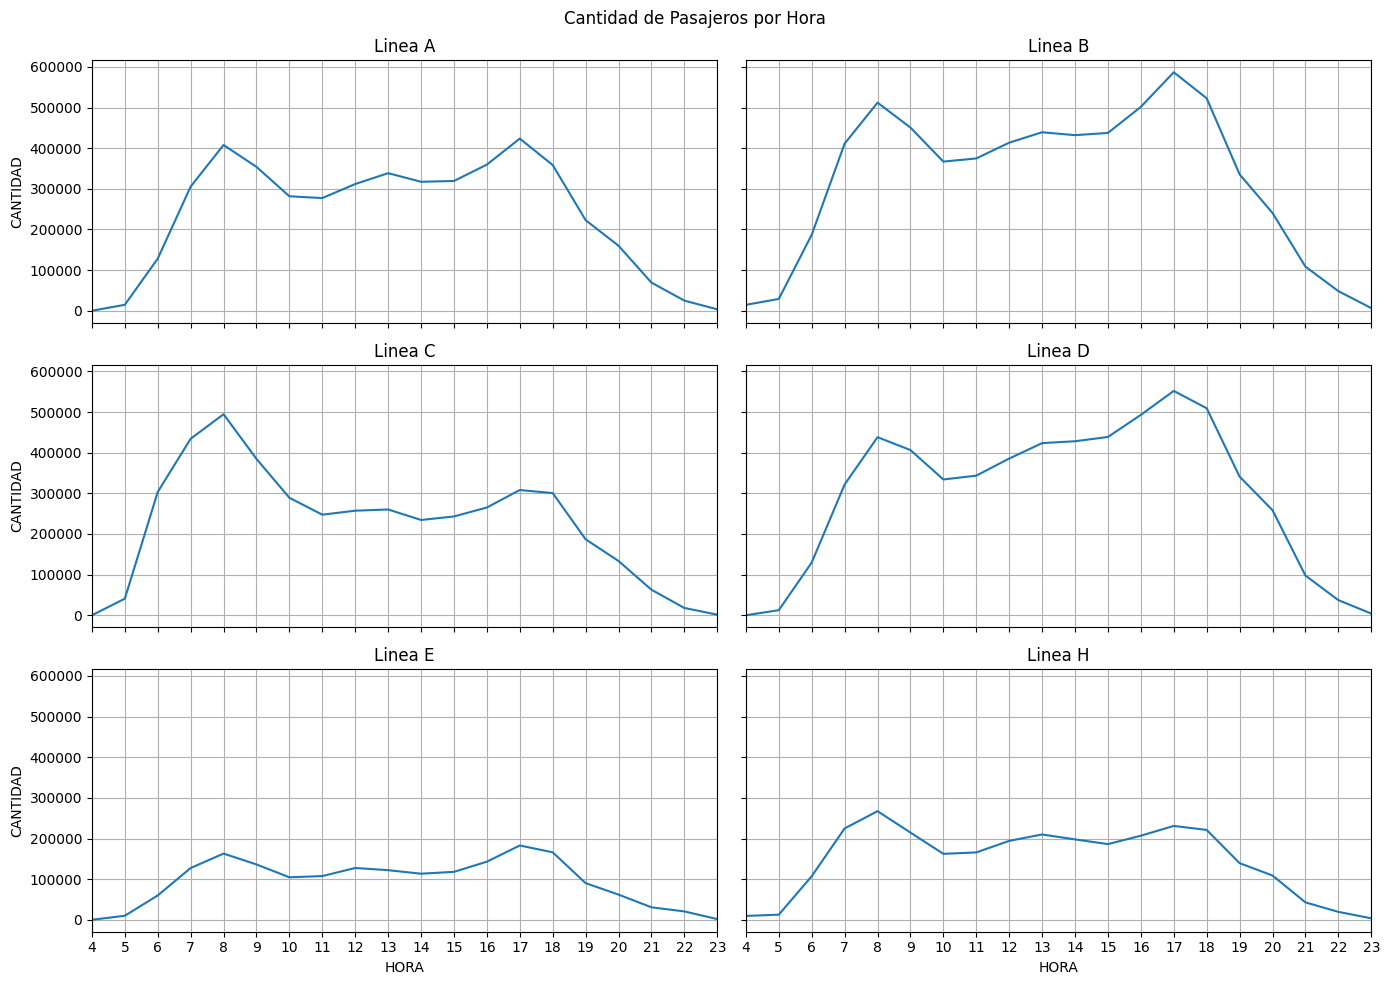

In [41]:
# agregación explícita de las horas

fig, ax = plt.subplots(3,2, figsize=(14, 10), sharex=True, sharey=True)
plt.suptitle('Cantidad de Pasajeros por Hora')

ax[0,0].set_xticks(np.arange(4, 24))
ax[0,0].set_xlim(4)

sns.lineplot(cantidad_pax_a, ax=ax[0,0])
ax[0,0].set_title('Linea A')
ax[0,0].grid(True)

sns.lineplot(cantidad_pax_b, ax=ax[0,1])
ax[0,1].set_title('Linea B')
ax[0,1].grid(True)

sns.lineplot(cantidad_pax_c, ax=ax[1,0])
ax[1,0].set_title('Linea C')
ax[1,0].grid(True)


sns.lineplot(cantidad_pax_d, ax=ax[1,1])
ax[1,1].set_title('Linea D')
ax[1,1].grid(True)

sns.lineplot(cantidad_pax_e, ax=ax[2,0])
ax[2,0].set_title('Linea E')
ax[2,0].grid(True)

sns.lineplot(cantidad_pax_h, ax=ax[2,1])
ax[2,1].set_title('Linea H')
ax[2,1].grid(True)


plt.tight_layout()
plt.show()

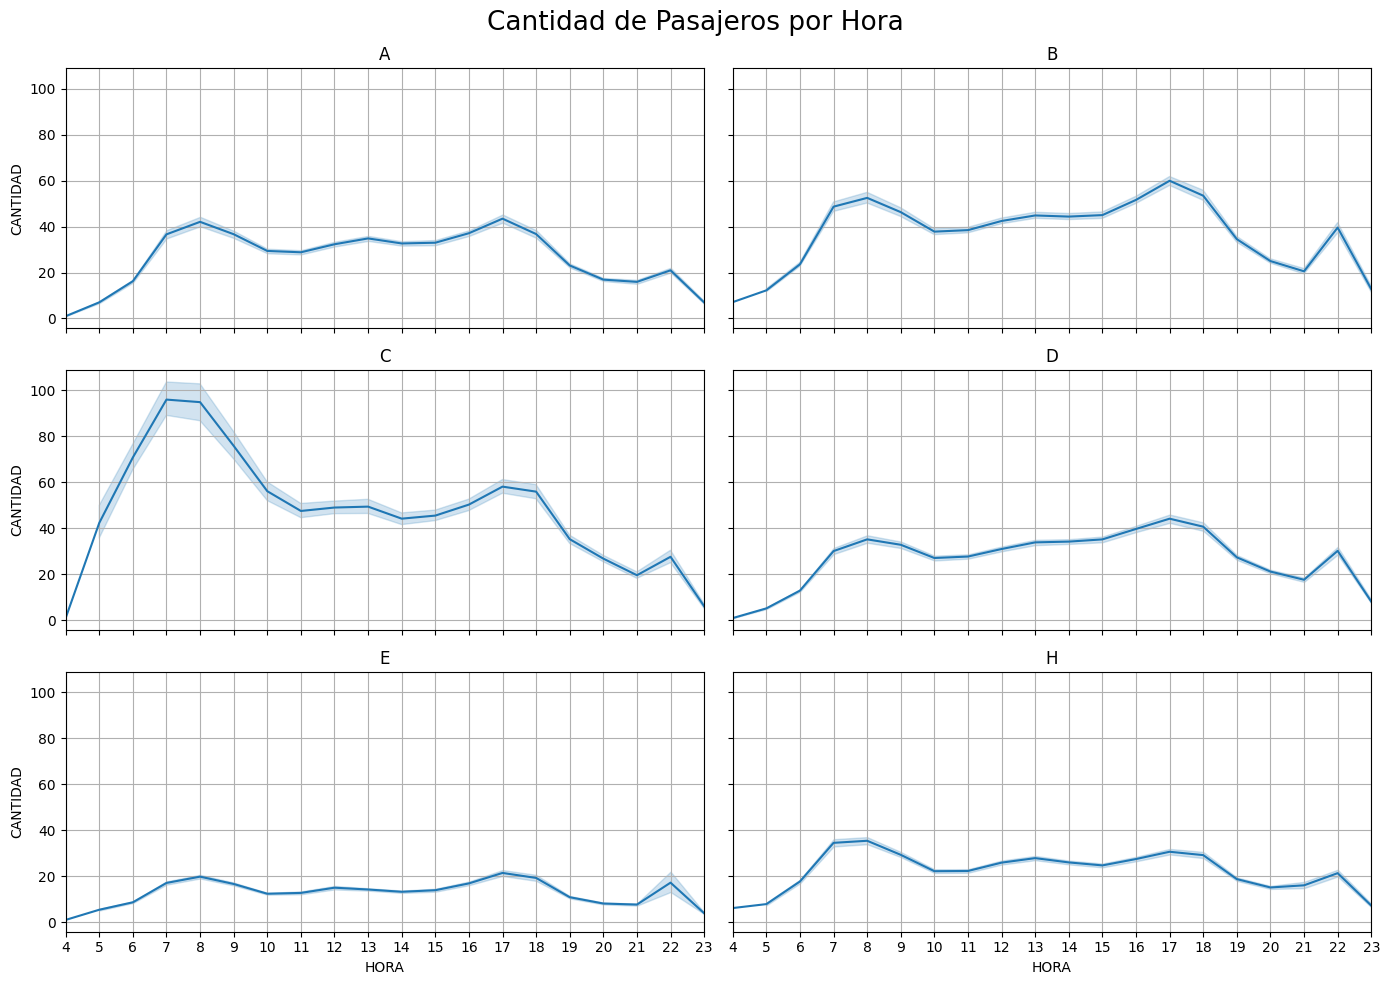

In [42]:
# estos gráficos están suavizados con estimator='mean

fig, ax = plt.subplots(3,2, figsize=(14, 10), sharex=True, sharey=True)
plt.suptitle('Cantidad de Pasajeros por Hora', size=19)

ax[0,0].set_xticks(np.arange(4, 24))
ax[0,0].set_xlim(4)

sns.lineplot(x='HORA', y='CANTIDAD', data=linea_a, ax=ax[0,0])
ax[0,0].set_title('A')
ax[0,0].grid(True)

sns.lineplot(x='HORA', y='CANTIDAD', data=linea_b, ax=ax[0,1])
ax[0,1].set_title('B')
ax[0,1].grid(True)

sns.lineplot(x='HORA', y='CANTIDAD', data=linea_c, ax=ax[1,0])
ax[1,0].set_title('C')
ax[1,0].grid(True)

sns.lineplot(x='HORA', y='CANTIDAD', data=linea_d, ax=ax[1,1])
ax[1,1].set_title('D')
ax[1,1].grid(True)

sns.lineplot(x='HORA', y='CANTIDAD', data=linea_e, ax=ax[2,0])
ax[2,0].set_title('E')
ax[2,0].grid(True)

sns.lineplot(x='HORA', y='CANTIDAD', data=linea_h, ax=ax[2,1])
ax[2,1].set_title('H')
ax[2,1].grid(True)


plt.tight_layout()
plt.show()

Se observa que las horas pico para todas las líneas son a las 8 y a las 17.
La línea C parece ser la de mayor volúmen de pasajeros por hora.

In [43]:
dias = df['FECHA'].dt.day_name()

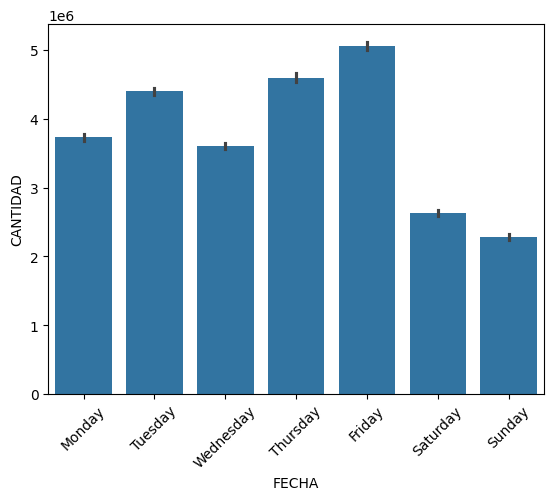

In [44]:
semana_ordenada = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.barplot(x=dias, y=df['CANTIDAD'], estimator=np.sum, order=semana_ordenada)
plt.xticks(rotation=45)
plt.show()

Vemos la distribución de pasajeros por cada día de la semana.

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [46]:
df_grouped = df.groupby("FECHA", as_index=False)["CANTIDAD"].sum() # agrupo por fecha y sumo cantidades
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   FECHA     264 non-null    datetime64[ns]
 1   CANTIDAD  264 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.3 KB


In [47]:
# Crear una serie de tiempo con el total de pasajeros por mes
# df_grouped['FECHA'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
subte_series = df_grouped.set_index('FECHA')['CANTIDAD'] # asigno la fecha como indice y me quedo con la columna "CANTIDAD"
subte_series.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 264 entries, 2020-01-03 to 2020-12-11
Series name: CANTIDAD
Non-Null Count  Dtype
--------------  -----
264 non-null    int64
dtypes: int64(1)
memory usage: 4.1 KB


In [48]:
subte_series = subte_series.asfreq("D")  # ensure daily frequency, el df tiene los datos por día
subte_series.info()
subte_series = subte_series.dropna()

<class 'pandas.core.series.Series'>
DatetimeIndex: 344 entries, 2020-01-03 to 2020-12-11
Freq: D
Series name: CANTIDAD
Non-Null Count  Dtype  
--------------  -----  
264 non-null    float64
dtypes: float64(1)
memory usage: 5.4 KB


In [49]:
subte_series.isna().sum()

np.int64(0)

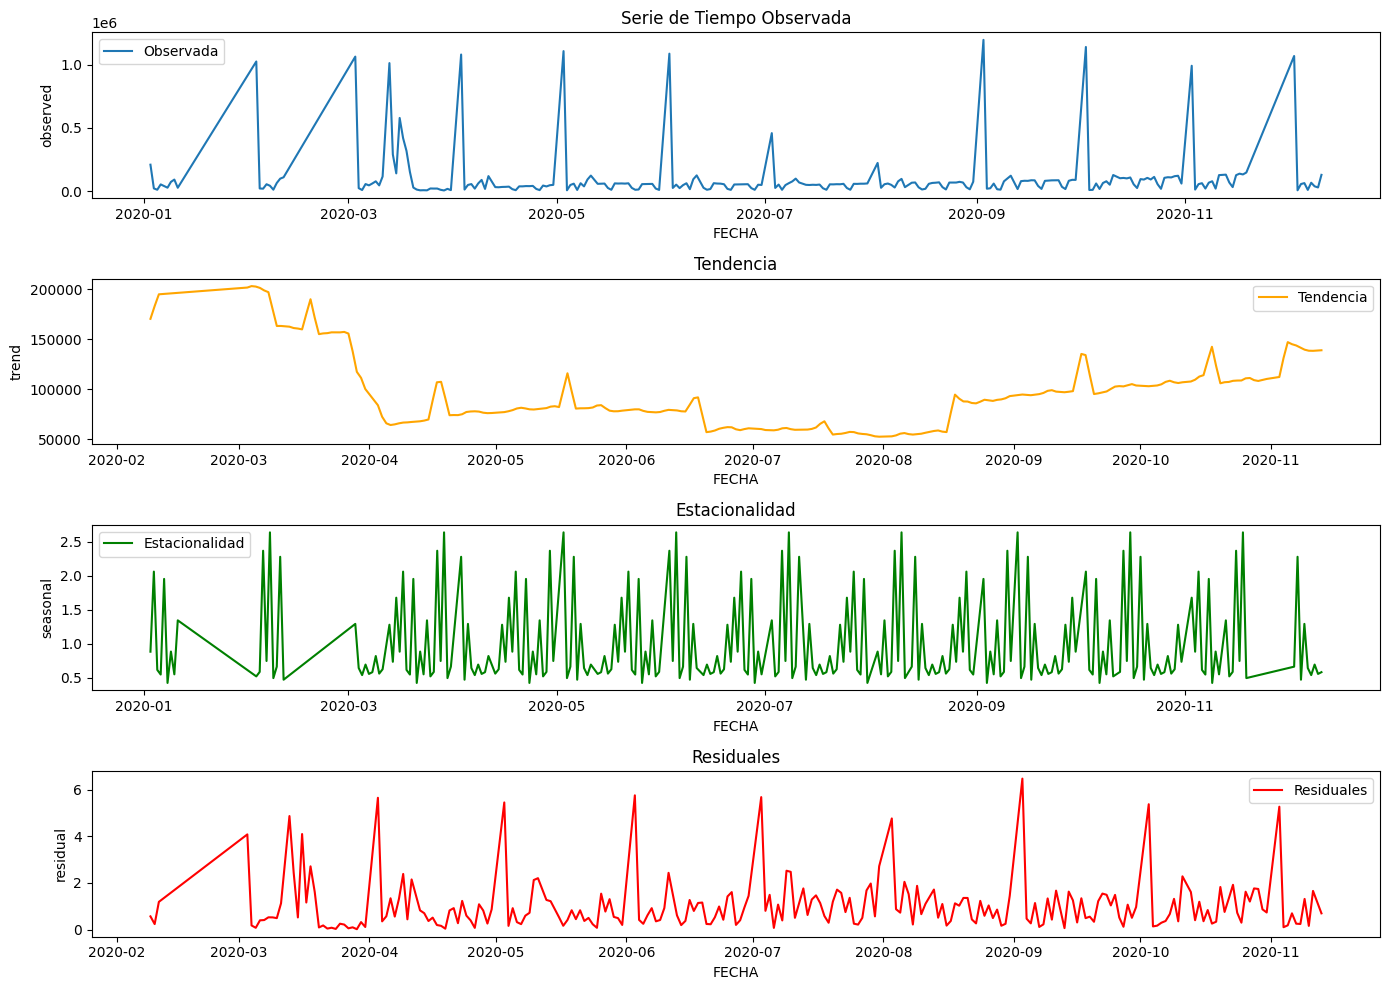

In [50]:
# Descomposición de series de tiempo
result = seasonal_decompose(subte_series, model="multiplicative", period=30)  # for daily data with monthly seasonality

# Preparar los datos para Seaborn
decomp_df = pd.DataFrame({
    'observed': result.observed,
    'trend': result.trend,
    'seasonal': result.seasonal,
    'residual': result.resid
}).reset_index()

# Visualización con Seaborn
plt.figure(figsize=(14, 10))

# Observed
plt.subplot(411)
sns.lineplot(data=decomp_df, x='FECHA', y='observed', label='Observada')
plt.title('Serie de Tiempo Observada')

# Trend
plt.subplot(412)
sns.lineplot(data=decomp_df, x='FECHA', y='trend', label='Tendencia', color='orange')
plt.title('Tendencia')

# Seasonal
plt.subplot(413)
sns.lineplot(data=decomp_df, x='FECHA', y='seasonal', label='Estacionalidad', color='green')
plt.title('Estacionalidad')

# Residual
plt.subplot(414)
sns.lineplot(data=decomp_df, x='FECHA', y='residual', label='Residuales', color='red')
plt.title('Residuales')

plt.tight_layout()
plt.show()